In [ ]:
#%pip install scipy

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------------------- ------------------ 30.7/61.0 kB 640.0 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 806.3 kB/s eta 0:00:00
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   - -------------------------------------- 0.5/15.8 MB 10.9 MB/s eta 0:00:02
   ----- ---------------------------------- 2.0/15.8 MB 25.9 MB/s eta 0:00:01
   --------- ------------------------------ 4.0/15.8 MB 31.5 MB/s eta 0:00:01
   -------------- ------------------------- 5.7/15.8 MB 33.2 MB/s eta 0:00:01
   ------------------- -------------------- 7.6/15.8 MB 34.7 MB/s eta 0:00:01
   ---------------------- ----------------- 8.9/15.8 MB 33.4 MB/s eta 0:00:01
   --------------------------- ------------ 11.0/15.8 MB 40.9 MB/s eta 0:00:01
   -------------------------------- ------- 12.9/15.8 MB 38.5 MB/s eta 0:00:01
   ------------------------------------ --- 14.6/15.8 MB 40.9 MB/s eta 0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
streamlit 1.30.0 requires packaging<24,>=16.8, but you have packaging 26.0 which is incompatible.
streamlit 1.30.0 requires pillow<11,>=7.1.0, but you have pillow 12.1.1 which is incompatible.


In [25]:
import pandas as pd
import seaborn
import matplotlib.pyplot as plt

In [ ]:
#Open and read the dataset file
with open("dataset_", "r") as f:
    lines = f.readlines()

#Skip to where the data actually starts in the file
data_start = next(i for i, line in enumerate(lines) if "@DATA" in line)

#From here parse the dataset into a usable variable
dataset = pd.read_csv("dataset_", skiprows=data_start+1, header=None)

#Get the feature column
dataset.columns = ['id','rated','created_at','last_move_at','turns','victory_status','winner','increment_code','white_id','white_rating','black_id','black_rating','moves','opening_eco','opening_name','opening_ply']


dataset.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,'2017-08-31 20:06:40','2017-08-31 20:06:40',13,outoftime,white,15+2,bourgris,1500,a-00,1191,'d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba...,D10,'Slav Defense: Exchange Variation',5
1,l1NXvwaE,True,'2017-08-30 21:53:20','2017-08-30 21:53:20',16,resign,black,5+10,a-00,1322,skinnerua,1261,'d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc...,B00,'Nimzowitsch Defense: Kennedy Variation',4
2,mIICvQHh,True,'2017-08-30 21:53:20','2017-08-30 21:53:20',61,mate,white,5+10,ischia,1496,a-00,1500,'e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 N...,C20,'King\'s Pawn Game: Leonardis Variation',3
3,kWKvrqYL,True,'2017-08-30 16:20:00','2017-08-30 16:20:00',61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,'d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 ...,D02,'Queen\'s Pawn Game: Zukertort Variation',3
4,9tXo1AUZ,True,'2017-08-29 18:06:40','2017-08-29 18:06:40',95,mate,white,30+3,nik221107,1523,adivanov2009,1469,'e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 ...,C41,'Philidor Defense',5


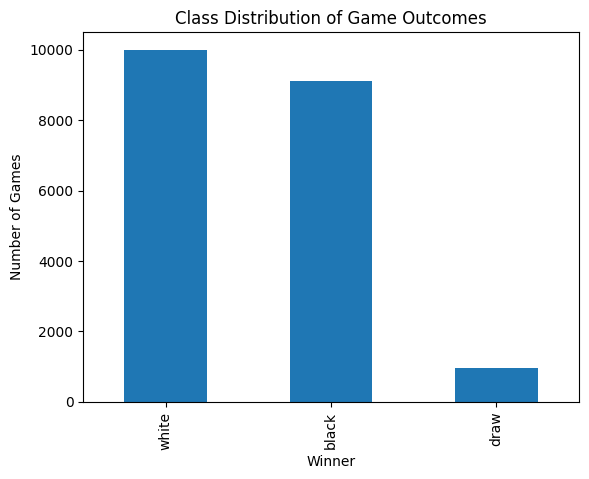

In [ ]:
#get the number of each game outcome
class_counts = dataset["winner"].value_counts()

#Create a bar chart of the game outcomes
plt.figure()
class_counts.plot(kind="bar")

plt.title("Class Distribution of Game Outcomes")
plt.xlabel("Game Outcome")
plt.ylabel("Number of Games")

plt.show()

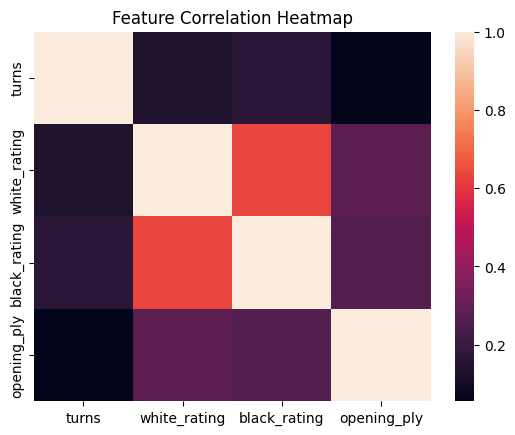

In [27]:
#use only the numeric features
numeric_features = dataset[[
    "turns",
    "white_rating",
    "black_rating",
    "opening_ply"
]]

#Create a correlation matrix
corr_matrix = numeric_features.corr()

# Plot feature heatmap
plt.figure()
seaborn.heatmap(corr_matrix)

plt.title("Feature Correlation Heatmap")
plt.show()